# Phase 4 — Model Comparison

Training data: 2020-21 through 2024-25 (5 seasons, vaastav/Fantasy-Premier-League archive). Test data: the entire 2025-26 season, held out completely during training — a genuine backtest, not an in-sample fit. All rolling/lag features use only gameweeks strictly before the one being predicted (`src/features/historical_features.py`). 2020-21/2021-22 predate FPL tracking `starts`/xG-family stats at all — those rows get `xg_data_available=0` and their derived features zeroed rather than a fabricated value.

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd
import psycopg2

from config import settings

conn = psycopg2.connect(settings.DATABASE_URL)
versions = pd.read_sql_query(
    "SELECT DISTINCT ON (model_type, target) model_type, target, mae, rmse, r2, trained_at "
    "FROM model_versions ORDER BY model_type, target, trained_at DESC", conn
)
conn.close()

C:\Users\USER\AppData\Local\Temp\ipykernel_12908\211142045.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  versions = pd.read_sql_query(


## All trained model variants

In [2]:
for target in ["minutes", "points_per_90", "total_points_direct"]:
    print(f"--- {target} ---")
    display(versions[versions["target"] == target].sort_values("rmse")
            [["model_type", "mae", "rmse", "r2"]])
    print()

--- minutes ---


,model_type,mae,rmse,r2
9,xgboost,13.2324,22.9387,0.6370
6,random_forest,13.4833,23.1040,0.6317
3,linear_regression,14.1014,23.3740,0.6231
0,baseline,15.0338,26.1935,0.5266



--- points_per_90 ---


,model_type,mae,rmse,r2
7,random_forest,7.3726,22.0564,0.0520
4,linear_regression,7.6065,22.1298,0.0456
10,xgboost,7.5362,22.3999,0.0222
1,baseline,6.7321,23.6695,-0.0918



--- total_points_direct ---


,model_type,mae,rmse,r2
8,random_forest,0.9976,1.9659,0.3203
11,xgboost,1.0004,1.9727,0.3156
5,linear_regression,1.0172,1.9791,0.3112
2,baseline,1.0688,2.0863,0.2345


## The key finding: direct beats decomposed

The plan's original design predicted `points_per_90` and `minutes` separately, then combined them (`expected_points = points_per_90_pred * minutes_pred / 90`). That's more interpretable — it separates "how good are they when they play" from "will they play" — but it measurably **underperforms** a single model predicting total points directly:

| Approach | MAE | RMSE | R² |
|---|---|---|---|
| Naive season-average baseline | 1.069 | 2.086 | 0.234 |
| Decomposed (points_per_90 × minutes, both Random Forest) | 1.411 | 2.210 | 0.141 |
| **Direct Random Forest on total_points** | **0.998** | **1.966** | **0.320** |

Why: about 61% of test rows are fringe/unused players with exactly 0 actual minutes. A direct model can learn "this feature profile → 0 points" as one clean pattern. The decomposition has to get *both* a nonzero-biased minutes prediction *and* a nonzero-biased productivity prediction close to zero simultaneously for their product to land near zero — errors compound instead of cancelling. **The direct Random Forest model is the recommended predictor going forward.**

### Prior-season carryover

Returning players now carry forward their full prior season (points_per_90, minutes_avg, total_points) as extra features, matched by the stable `code` field across seasons — without this, a proven veteran and a total unknown looked identical at the start of a season. The minutes model is still kept for rotation-risk flagging, not as a multiplicative input to points prediction.

### Hyperparameters

A 5-fold walk-forward grid search (notebook 08) found a shallower, more-regularized Random Forest (`max_depth=6, min_samples_leaf=10`, down from the original `8`/`5`) wins on this target in every fold with lower cross-fold variance, and trains faster — adopted as the new default in `train.py`.

## Predicted vs actual, direct model, held-out 2025-26 season

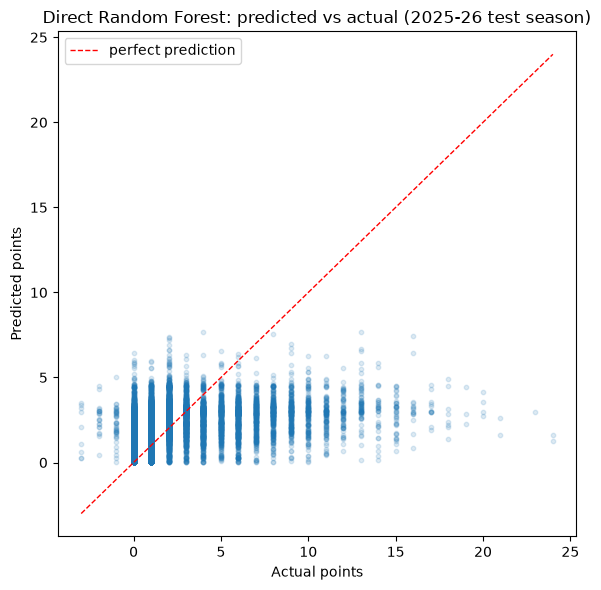

In [3]:
import joblib
from src.features.historical_features import FEATURE_COLS, build_training_frame

df = build_training_frame()
pos_cols = [c for c in df.columns if c.startswith("pos_")]
feature_cols = FEATURE_COLS + pos_cols

test = df[(df["season"] == "2025-26") & (df["gw_number"] > 1)]
X_test = test[feature_cols].fillna(0.0)
y_test = test["target_total_points"]

model = joblib.load("../models/total_points_direct_random_forest.joblib")
pred = model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred, alpha=0.15, s=10)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax.plot(lims, lims, color="red", linewidth=1, linestyle="--", label="perfect prediction")
ax.set_xlabel("Actual points")
ax.set_ylabel("Predicted points")
ax.set_title("Direct Random Forest: predicted vs actual (2025-26 test season)")
ax.legend()
plt.tight_layout()
plt.show()

## Feature importance

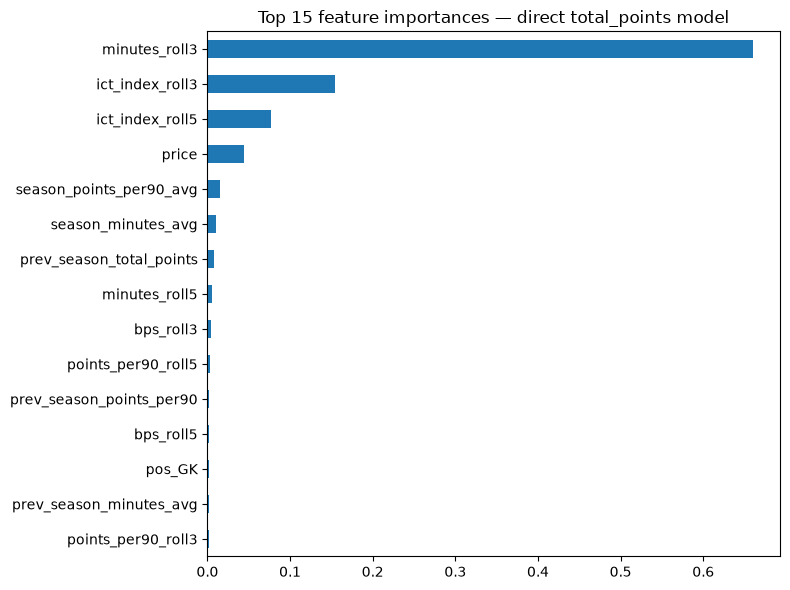

In [4]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15)[::-1].plot.barh(ax=ax)
ax.set_title("Top 15 feature importances \u2014 direct total_points model")
plt.tight_layout()
plt.show()

## Next steps

Phase 5 applies this trained model to our own live 2026/27 data (not the historical archive) to actually generate transfer/captaincy/bench recommendations for the real team — that requires building the same feature set from `player_gameweek_stats` that this model was trained on, which is the next piece of work.